In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

In [33]:
def load_and_explore_data(filepath='data.csv'):
    """Load data and perform initial exploration"""
    df = pd.read_csv(filepath)
    
    print("=" * 60)
    print("DATASET OVERVIEW")
    print("=" * 60)
    print(f"Shape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nData Types:\n{df.dtypes}")
    print(f"\nMissing Values:\n{df.isnull().sum()}")
    print(f"\nTarget Distribution:\n{df['Creditworthiness'].value_counts()}")
    print(f"\nTarget Ratio: {df['Creditworthiness'].mean():.2%} creditworthy")
    
    return df

In [34]:
def preprocess_data(df):
    """Preprocess the data for modeling"""
    df_processed = df.copy()
    
    # Encode categorical variables
    categorical_cols = ['Gender', 'Education', 'Payment_History', 
                       'Employment_Status', 'Residence_Type', 'Marital_Status']
    
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col])
        label_encoders[col] = le
    
    # Separate features and target
    X = df_processed.drop('Creditworthiness', axis=1)
    y = df_processed['Creditworthiness']
    
    # Feature engineering - create useful ratios
    X['Debt_to_Income'] = X['Debt'] / (X['Income'] + 1)
    X['Loan_to_Income'] = X['Loan_Amount'] / (X['Income'] + 1)
    X['Credit_Utilization'] = X['Debt'] / (X['Credit_Score'] + 1)
    
    print(f"\nFeatures created: {X.shape[1]} total features")
    
    return X, y, label_encoders


In [ ]:
def train_models(X, y, test_size=0.2, random_state=42):
    """Train and compare multiple models"""
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Handle class imbalance with SMOTE
    smote = SMOTE(random_state=random_state)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
    
    print(f"\nOriginal training set: {len(y_train)} samples")
    print(f"After SMOTE: {len(y_train_balanced)} samples")
    print(f"Class distribution after SMOTE: {np.bincount(y_train_balanced)}")
    
    # Define models
    models = {
        'Logistic Regression': LogisticRegression( class_weight='balanced', random_state=random_state, max_iter=1000),
        'Random Forest': RandomForestClassifier( class_weight='balanced', random_state=random_state, n_estimators=100),
        'Gradient Boosting': GradientBoostingClassifier( random_state=random_state, n_estimators=100),
        'XGBoost': XGBClassifier( scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
            random_state=random_state, n_estimators=100, use_label_encoder=False,eval_metric='logloss'),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
    }
    
    results = []
    
    print("\n" + "=" * 60)
    print("MODEL TRAINING & EVALUATION")
    print("=" * 60)
    
    for name, model in models.items():
        print(f"\nTraining {name}...")
        
        # Train model
        if name == 'K-Nearest Neighbors':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train_balanced, y_train_balanced)
            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        # Calculate metrics
        metrics = {
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
            'Model_Object': model,
            'Predictions': y_pred,
            'Probabilities': y_pred_proba
        }
        
        results.append(metrics)
        
        print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
        print(f"  Precision: {metrics['Precision']:.4f}")
        print(f"  Recall:    {metrics['Recall']:.4f}")
        print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
        print(f"  ROC-AUC:   {metrics['ROC-AUC']:.4f}")
    
    return results, X_test, y_test, scaler, X_train.columns


In [36]:
def evaluate_best_model(results, X_test, y_test, feature_names):
    """Detailed evaluation of the best model"""
    
    # Find best model based on F1-Score
    best_model = max(results, key=lambda x: x['F1-Score'])
    
    print("\n" + "=" * 60)
    print("BEST MODEL EVALUATION")
    print("=" * 60)
    print(f"Best Model: {best_model['Model']}")
    print(f"F1-Score: {best_model['F1-Score']:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, best_model['Predictions'], 
                               target_names=['Not Creditworthy', 'Creditworthy']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, best_model['Predictions'])
    print("\nConfusion Matrix:")
    print(cm)
    
    # Feature importance (if available)
    if hasattr(best_model['Model_Object'], 'feature_importances_'):
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': best_model['Model_Object'].feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print("\nTop 10 Most Important Features:")
        print(importance_df.head(10).to_string(index=False))
        
        return best_model, importance_df
    
    return best_model, None

In [37]:

def create_visualizations(results, y_test, best_model, importance_df=None):
    """Create evaluation visualizations"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Model Comparison
    ax1 = axes[0, 0]
    model_names = [r['Model'] for r in results]
    f1_scores = [r['F1-Score'] for r in results]
    auc_scores = [r['ROC-AUC'] for r in results]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    ax1.bar(x - width/2, f1_scores, width, label='F1-Score', color='steelblue')
    ax1.bar(x + width/2, auc_scores, width, label='ROC-AUC', color='coral')
    ax1.set_xlabel('Model')
    ax1.set_ylabel('Score')
    ax1.set_title('Model Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. ROC Curve
    ax2 = axes[0, 1]
    fpr, tpr, _ = roc_curve(y_test, best_model['Probabilities'])
    ax2.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f"ROC Curve (AUC = {best_model['ROC-AUC']:.2f})")
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve')
    ax2.legend(loc='lower right')
    ax2.grid(alpha=0.3)
    
    # 3. Precision-Recall Curve
    ax3 = axes[1, 0]
    precision, recall, _ = precision_recall_curve(y_test, best_model['Probabilities'])
    ax3.plot(recall, precision, color='blue', lw=2, 
             label=f"PR Curve (F1 = {best_model['F1-Score']:.2f})")
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_title('Precision-Recall Curve')
    ax3.legend(loc='lower left')
    ax3.grid(alpha=0.3)
    
    # 4. Feature Importance (if available)
    ax4 = axes[1, 1]
    if importance_df is not None:
        top_features = importance_df.head(10)
        ax4.barh(range(len(top_features)), top_features['Importance'].values)
        ax4.set_yticks(range(len(top_features)))
        ax4.set_yticklabels(top_features['Feature'].values)
        ax4.set_xlabel('Importance')
        ax4.set_title('Top 10 Feature Importance')
        ax4.invert_yaxis()
        ax4.grid(axis='x', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Feature importance\nnot available', 
                ha='center', va='center', transform=ax4.transAxes)
    
    plt.tight_layout()
    plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
    print("\nVisualization saved as 'model_evaluation.png'")
    plt.show()

In [38]:

def save_model(best_model, scaler, label_encoders, feature_names):
    """Save the best model and preprocessing objects"""
    
    model_package = {
        'model': best_model['Model_Object'],
        'scaler': scaler,
        'label_encoders': label_encoders,
        'feature_names': feature_names,
        'metrics': {k: v for k, v in best_model.items() if k != 'Model_Object'}
    }
    
    pickle.dump(model_package, open('creditworthiness_model.pkl', 'wb'))
    print("\nModel saved as 'creditworthiness_model.pkl'")


In [39]:
def predict_new_data(new_data, model_package_path='creditworthiness_model.pkl'):
    """Make predictions on new data"""
    
    # Load model
    model_package = pickle.load(open(model_package_path, 'rb'))
    model = model_package['model']
    scaler = model_package['scaler']
    label_encoders = model_package['label_encoders']
    feature_names = model_package['feature_names']
    
    # Prepare new data
    df_new = new_data.copy()
    
    # Encode categorical variables
    for col, encoder in label_encoders.items():
        if col in df_new.columns:
            df_new[col] = encoder.transform(df_new[col])
    
    # Create engineered features
    df_new['Debt_to_Income'] = df_new['Debt'] / (df_new['Income'] + 1)
    df_new['Loan_to_Income'] = df_new['Loan_Amount'] / (df_new['Income'] + 1)
    df_new['Credit_Utilization'] = df_new['Debt'] / (df_new['Credit_Score'] + 1)
    
    # Ensure correct feature order
    X_new = df_new[feature_names]
    
    # Scale and predict
    X_new_scaled = scaler.transform(X_new)
    predictions = model.predict(X_new_scaled)
    probabilities = model.predict_proba(X_new_scaled)[:, 1]
    
    results = pd.DataFrame({
        'Prediction': predictions,
        'Probability': probabilities,
        'Creditworthy': ['Yes' if p == 1 else 'No' for p in predictions]
    })
    
    return results


CREDITWORTHINESS PREDICTION MODEL
DATASET OVERVIEW
Shape: (12000, 14)

Columns: ['Age', 'Gender', 'Education', 'Income', 'Debt', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Num_Credit_Cards', 'Payment_History', 'Employment_Status', 'Residence_Type', 'Marital_Status', 'Creditworthiness']

Data Types:
Age                   int64
Gender               object
Education            object
Income                int64
Debt                  int64
Credit_Score          int64
Loan_Amount           int64
Loan_Term             int64
Num_Credit_Cards      int64
Payment_History      object
Employment_Status    object
Residence_Type       object
Marital_Status       object
Creditworthiness      int64
dtype: object

Missing Values:
Age                  0
Gender               0
Education            0
Income               0
Debt                 0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Num_Credit_Cards     0
Payment_History      0
Employment_Status    0
Residence_Type       

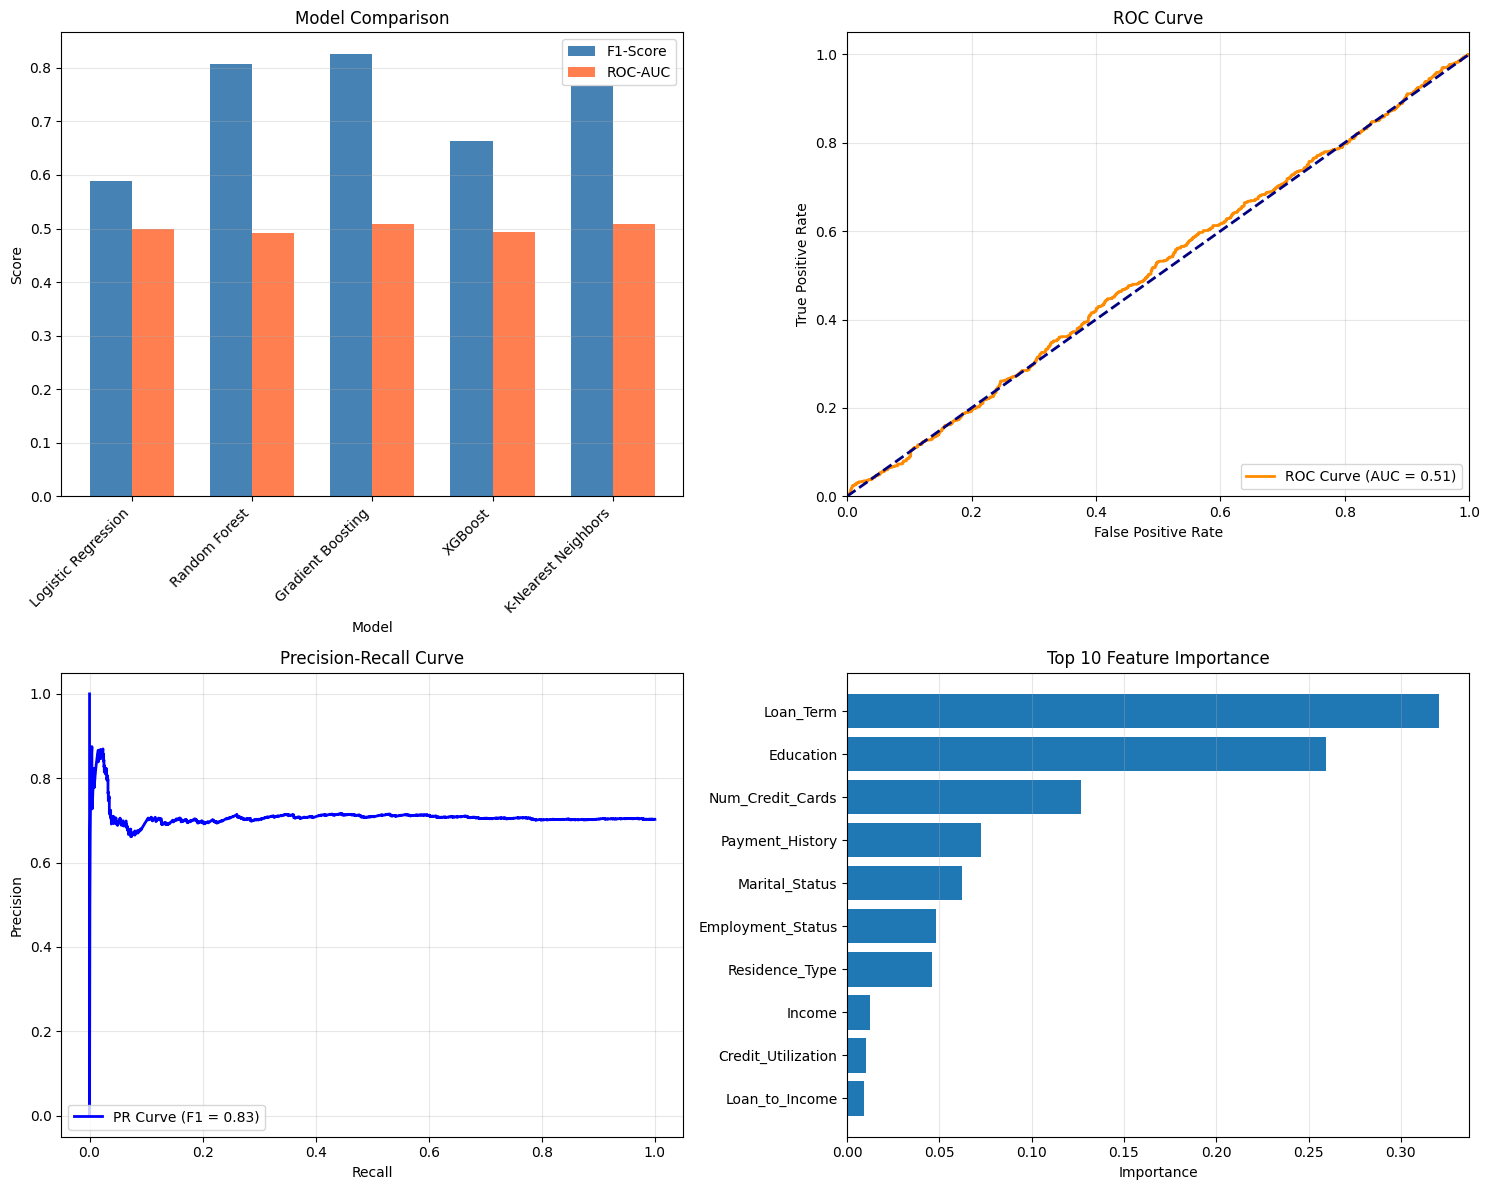


Model saved as 'creditworthiness_model.pkl'

EXAMPLE PREDICTION

Prediction: Yes
Probability: 60.87%

TRAINING COMPLETE!


In [40]:
if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("CREDITWORTHINESS PREDICTION MODEL")
    print("=" * 60)
    
    # Step 1: Load data
    df = load_and_explore_data('data.csv')
    
    # Step 2: Preprocess
    X, y, label_encoders = preprocess_data(df)
    
    # Step 3: Train models
    results, X_test, y_test, scaler, feature_names = train_models(X, y)
    
    # Step 4: Evaluate best model
    best_model, importance_df = evaluate_best_model(results, X_test, y_test, feature_names)
    
    # Step 5: Create visualizations
    create_visualizations(results, y_test, best_model, importance_df)
    
    # Step 6: Save model
    save_model(best_model, scaler, label_encoders, feature_names)
    
    # Step 7: Example prediction
    print("\n" + "=" * 60)
    print("EXAMPLE PREDICTION")
    print("=" * 60)
    
    example_data = pd.DataFrame([{
        'Age': 35,
        'Gender': 'Male',
        'Education': 'Bachelor',
        'Income': 75000,
        'Debt': 15000,
        'Credit_Score': 720,
        'Loan_Amount': 25000,
        'Loan_Term': 36,
        'Num_Credit_Cards': 3,
        'Payment_History': 'Good',
        'Employment_Status': 'Employed',
        'Residence_Type': 'Owned',
        'Marital_Status': 'Married'
    }])
    
    prediction = predict_new_data(example_data)
    print(f"\nPrediction: {prediction['Creditworthy'].values[0]}")
    print(f"Probability: {prediction['Probability'].values[0]:.2%}")
    
    print("\n" + "=" * 60)
    print("TRAINING COMPLETE!")
    print("=" * 60)

In [41]:
#final dataset and model are saved in the current directory.

